In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import plotly.express as px


# Load the cleaned and scaled data 
df = pd.read_csv('../data/processed/cleaned_feature_matrix.csv')

# drop gdp
df.drop(columns='log_gdp_pc')

# Separate IDs from Features
ids = df[['country_code', 'Name', 'year']]
features = df.drop(columns=['country_code', 'Name', 'year'])

# Convert to PyTorch Tensor
X_tensor = torch.FloatTensor(features.values)
input_dim = features.shape[1]



In [40]:
class ClimateTrajectoryAE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3) # The 3D Latent Bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        decoded = self.decoder(latent)
        return latent, decoded

model = ClimateTrajectoryAE(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# Training Loop
epochs = 1000 
for epoch in range(epochs):
    latent, decoded = model(X_tensor)
    loss = criterion(decoded, X_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.6f}")

Epoch 200/1000 | Loss: 0.200279
Epoch 400/1000 | Loss: 0.141504
Epoch 600/1000 | Loss: 0.123713
Epoch 800/1000 | Loss: 0.111622
Epoch 1000/1000 | Loss: 0.103917


In [41]:
# Get Latent coordinates
model.eval()
with torch.no_grad():
    latent_coords, _ = model(X_tensor)
    latent_coords = latent_coords.numpy()

# Create a clean dataframe for Plotly
df_viz = pd.DataFrame(latent_coords, columns=['Dim1', 'Dim2', 'Dim3'])
df_viz = pd.concat([ids.reset_index(drop=True), df_viz], axis=1)

# Sort by country and year to ensure the lines draw in order!
df_viz = df_viz.sort_values(['country_code', 'year'])

# Plotly 3D Trajectory Map
fig = px.line_3d(
    df_viz, 
    x='Dim1', y='Dim2', z='Dim3',
    color='country_code',      # Each country gets its own color
    line_group='country_code', # This draws the "Snakes"
    hover_name='Name',
    hover_data=['year'],
    title="20-Year Climate Action Trajectories",
    template='plotly_dark'
)

fig.show()

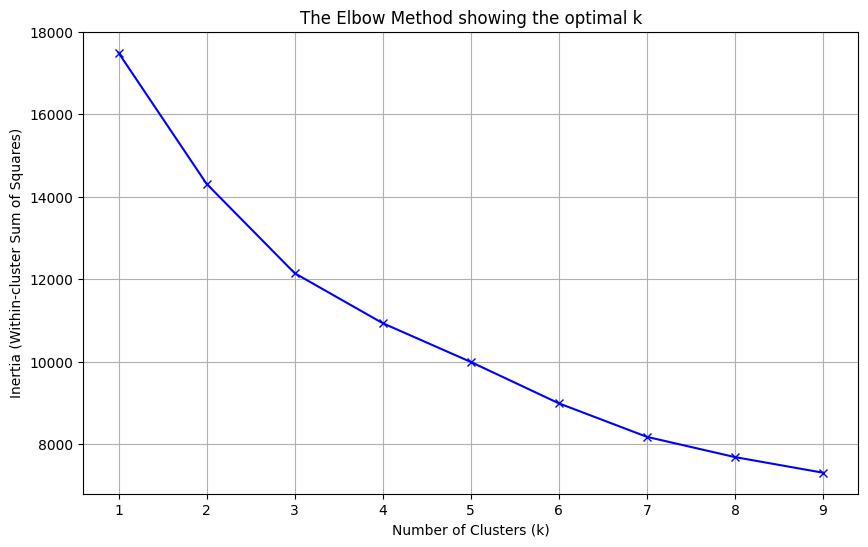

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, PowerTransformer
import pandas as pd

# Calculate Inertia for different 'K' values
# Inertia is the sum of squared distances of samples to their closest cluster center.

inertia = []
K_range = range(1, 10) # Testing 1 to 9 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True)
plt.show()

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px

# Run KMeans on the 1,300 points
n_states = 4
kmeans = KMeans(n_clusters=n_states, random_state=42, n_init=10)
df_viz['state_cluster'] = kmeans.fit_predict(latent_coords)

# Check the Trust Score
score = silhouette_score(latent_coords, df_viz['state_cluster'])
print(f"Silhouette Score for 1,300 points: {score:.4f}")

# 3D Plot with 'Snakes' colored by Country, but Points colored by State
fig = px.scatter_3d(
    df_viz, 
    x='Dim1', y='Dim2', z='Dim3',
    color='state_cluster',        # Color shows the 'Regime'
    hover_name='Name',
    hover_data=['year'],
    title=f"Climate Transitions (N=1300)",
    template='plotly_dark',
    opacity=0.7
)

# Optional: Add the lines back in to see the paths through the clusters
fig.update_traces(mode='markers+lines') 
fig.show()

Silhouette Score for 1,300 points: 0.3403


In [44]:
print("--- Country Cluster Sequences (2000 -> 2020) ---")
# Sort for chronological logic
df_final_labels = df_viz[['Name', 'year', 'state_cluster']].sort_values(['Name', 'year'])

for country in df_final_labels['Name'].unique():
    # Get the sequence of clusters for this country
    sequence = df_final_labels[df_final_labels['Name'] == country]['state_cluster'].tolist()
    
    # Format the sequence as a string: "0 -> 0 -> 1 -> 2"
    path_string = " -> ".join(map(str, sequence))
    
    print(f"{country.ljust(20)} | {path_string}")

--- Country Cluster Sequences (2000 -> 2020) ---
Argentina            | 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 3 -> 3 -> 3
Australia            | 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3
Austria              | 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 0 -> 0 -> 0 -> 0
Belgium              | 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 0 -> 0 -> 0 -> 0
Brazil               | 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1
Canada               | 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 3 -> 0 -> 0 -> 0 -> 0
Chile                | 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 3 -> 3 -> 3 -> 3 -> 0 -> 0 -> 0
China                | 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -> 1 -

# Seeing how I can make this useful

In [45]:
# Calculate the distance moved in 3D space year-over-year
df_viz['dist_moved'] = df_viz.groupby('country_code').apply(
    lambda x: np.sqrt(x['Dim1'].diff()**2 + x['Dim2'].diff()**2 + x['Dim3'].diff()**2)
).reset_index(level=0, drop=True)

# Identify Cluster Changes
df_viz['prev_state'] = df_viz.groupby('country_code')['state_cluster'].shift(1)
df_viz['regime_jump'] = df_viz['state_cluster'] != df_viz['prev_state']

# Ignore the first year (2000) because it will always show a jump
df_viz.loc[df_viz['year'] == 2000, 'regime_jump'] = False

# Filter for the largest transitions (Top 5% of distance moved)
threshold = df_viz['dist_moved'].quantile(0.95)
top_jumps = df_viz[df_viz['dist_moved'] > threshold]

print("--- Top 5 Structural Jumps Detected ---")
print(top_jumps[['Name', 'year', 'dist_moved', 'state_cluster', 'regime_jump']].sort_values(by='dist_moved', ascending=False).head(10))

--- Top 5 Structural Jumps Detected ---
            Name  year  dist_moved  state_cluster  regime_jump
732  New Zealand  2018   39.740307              2         True
272      Denmark  2020   30.370071              2         True
143  Switzerland  2017   19.265024              0         True
626   Luxembourg  2017   16.663916              0         True
165        Chile  2018   15.709109              0         True
332      Finland  2017   13.426112              0         True
606    Lithuania  2018   12.681672              0         True
353       France  2017   12.378964              0         True
397       Greece  2019   12.247694              0         True
941       Sweden  2017   11.929367              0         True
